In [72]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [73]:
with open("processed_battery_features_v2.pkl", "rb") as f:
    feature_df = pickle.load(f)

In [74]:
model_df = feature_df.dropna().copy()

feature_columns = [
    'I_mean',
    'I_std',
    'charge_duration',
    # 'discharge_duration',
    'V_mean',
    'V_std',


    # neue Spannungskurven-Features
    'V_range',
    'V_slope_mean',
    'V_curvature',
    'V_n_peaks',

    # Kurvendynamik
    'RMSE_V',
    'AreaDiff_V',
    'Corr_V',
    'MaxDev_V',
    'SlopeRMSE_V',
    'DTW_I',
    'DTW_V'

]


feature_columns_durationless  = [
    'I_mean',
    'I_std',
    'charge_duration',
    'discharge_duration',
    'V_mean',
    'V_std',


    # neue Spannungskurven-Features
    'V_range',
    'V_slope_mean',
    'V_curvature',
    'V_n_peaks',

    # Kurvendynamik
    'RMSE_V',
    'AreaDiff_V',
    'Corr_V',
    'MaxDev_V',
    'SlopeRMSE_V',
    'DTW_I',
    'DTW_V'

]



target_column = "SOH"

features = model_df[feature_columns]
target = model_df[target_column]

In [75]:
# Aufteilen in Trainings- und Testdaten
features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [76]:
# Einfaches Random Forest Regressor Modell

model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(features_train, target_train)

pred_test = model_rf.predict(features_test)

In [77]:


print("MAE:", mean_absolute_error(target_test, pred_test))
print("R2:", r2_score(target_test, pred_test))

MAE: 0.003751196293477935
R2: 0.9935026389386927


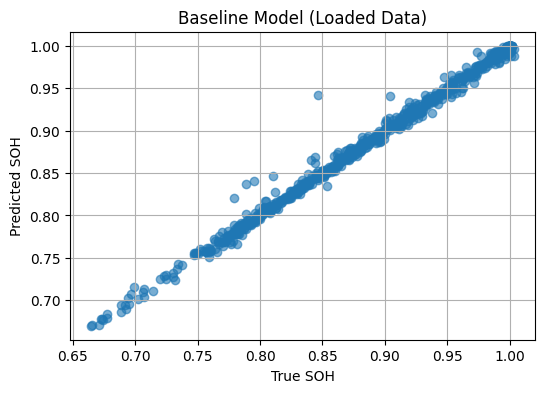

In [78]:
# Visualisierung der Vorhersagen
plt.figure(figsize=(6,4))

plt.scatter(target_test, pred_test, alpha=0.6)

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Baseline Model (Loaded Data)")
plt.grid(True)

plt.show()

In [79]:
importance_df = pd.DataFrame({
    "feature": features_train.columns,
    "importance": model_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df)

            feature  importance
15            DTW_V    0.693199
1             I_std    0.095710
2   charge_duration    0.077723
10       AreaDiff_V    0.027101
0            I_mean    0.025212
11           Corr_V    0.015281
3            V_mean    0.015020
8         V_n_peaks    0.011372
7       V_curvature    0.008293
14            DTW_I    0.006095
9            RMSE_V    0.005841
4             V_std    0.005481
12         MaxDev_V    0.005245
6      V_slope_mean    0.004528
13      SlopeRMSE_V    0.002010
5           V_range    0.001889


In [80]:
# plt.figure(figsize=(6, 4))

# plt.bar(
#     importance_df["feature"],
#     importance_df["importance"]
# )

# plt.ylabel("Importance")
# plt.title("Random Forest Feature Importance")

# plt.grid(axis="y")

# plt.show()

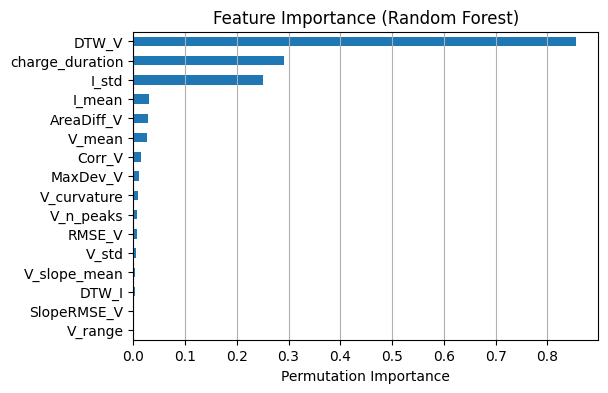

In [81]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_rf,                 # dein Random Forest
    features_test,
    target_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    result.importances_mean,
    index=features_test.columns
)

perm_importance.sort_values().plot(
    kind="barh",
    figsize=(6, 4)
)

plt.xlabel("Permutation Importance")
plt.title("Feature Importance (Random Forest)")
plt.grid(axis="x")
plt.show()

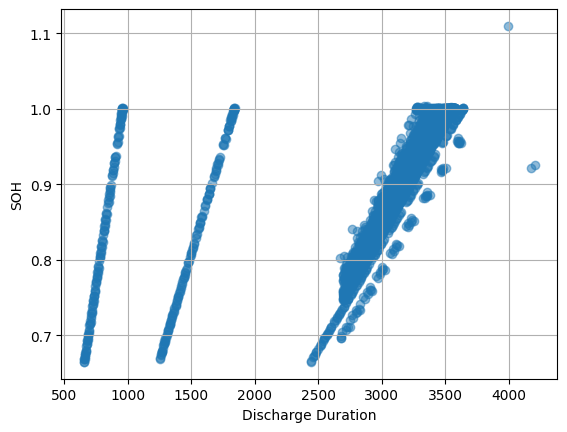

In [82]:
feature_df[["discharge_duration", "SOH"]].corr()

plt.scatter(
    feature_df["discharge_duration"],
    feature_df["SOH"],
    alpha=0.5
)

plt.xlabel("Discharge Duration")
plt.ylabel("SOH")
plt.grid(True)
plt.show()


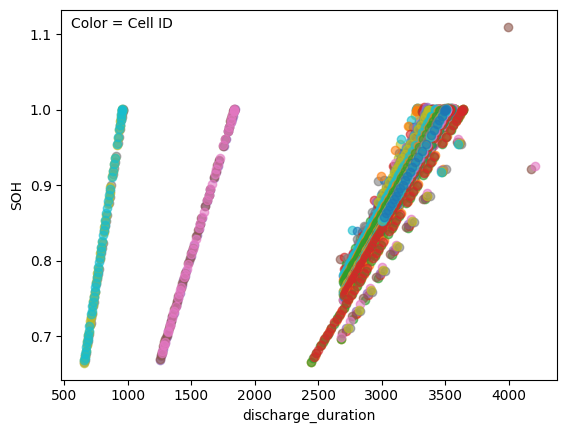

In [83]:
for cell_id, group in feature_df.groupby("cell_id"):
    plt.scatter(
        group["discharge_duration"],
        group["SOH"],
        label=cell_id,
        alpha=0.6
    )

plt.text(
    0.02, 0.98,
    "Color = Cell ID",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    # bbox=dict(boxstyle="round", alpha=0.8)
)

plt.xlabel("discharge_duration")
plt.ylabel("SOH")
# plt.legend()
plt.show()

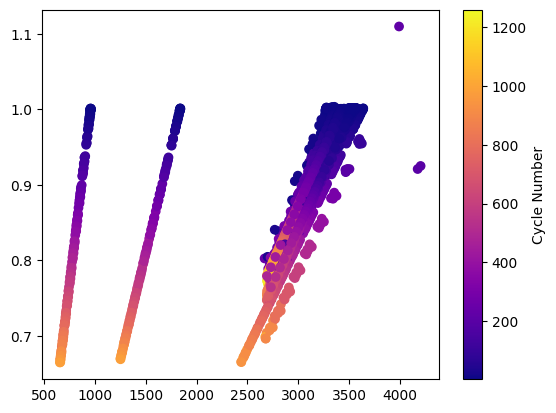

In [84]:
plt.scatter(
    feature_df["discharge_duration"],
    feature_df["SOH"],
    c=feature_df["cycle_number"],
    cmap="plasma"
)

plt.colorbar(label="Cycle Number")
plt.show()

In [85]:
feature_df["relative_discharge_duration"] = (
    feature_df["discharge_duration"]
    / feature_df.groupby("cell_id")["discharge_duration"].transform("first")
)

In [86]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd


def run_rf_experiment(
    df,
    feature_columns,
    target_column="SOH",
    test_size=0.2,
    random_state=42,
    n_estimators=200
):

    # -----------------------
    # 1. Data preparation
    # -----------------------
    data = df[feature_columns + [target_column]].dropna()

    features = data[feature_columns]
    target = data[target_column]

    features_train, features_test, target_train, target_test = train_test_split(
        features,
        target,
        test_size=test_size,
        random_state=random_state,
        shuffle=False  # wichtig bei time-like data
    )

    # -----------------------
    # 2. Model
    # -----------------------
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(features_train, target_train)

    # -----------------------
    # 3. Prediction + metrics
    # -----------------------
    pred = model.predict(features_test)

    mae = mean_absolute_error(target_test, pred)
    r2 = r2_score(target_test, pred)

    print("MAE:", round(mae, 4))
    print("R² :", round(r2, 4))

    # -----------------------
    # 4. Permutation importance
    # -----------------------
    result = permutation_importance(
        model,
        features_test,
        target_test,
        n_repeats=10,
        random_state=random_state,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": result.importances_mean,
        "std": result.importances_std
    }).sort_values("importance", ascending=False)

    print("\nFeature importance:")
    print(importance_df)

    # -----------------------
    # 5. Return everything
    # -----------------------
    return {
        "model": model,
        "mae": mae,
        "r2": r2,
        "importance": importance_df,
        "features_test": features_test,
        "target_test": target_test,
        "pred": pred
    }

In [87]:
voltage_features = [
    "DTW_V",
    "V_curvature",
    "V_std",
    "V_mean"
]

result_v = run_rf_experiment(feature_df, voltage_features)

MAE: 0.0113
R² : 0.8954

Feature importance:
       feature  importance       std
0        DTW_V    1.042201  0.035923
3       V_mean    0.568690  0.023364
1  V_curvature    0.266532  0.015414
2        V_std    0.187145  0.018719


In [88]:
best_features = [
    "DTW_V",
    "discharge_duration",
    "charge_duration"
]

result_best = run_rf_experiment(feature_df, best_features)

MAE: 0.0054
R² : 0.9871

Feature importance:
              feature  importance       std
1  discharge_duration    1.042241  0.041293
0               DTW_V    0.406176  0.023728
2     charge_duration    0.035599  0.001679


In [89]:
all_features = [
    "DTW_V",
    "DTW_I",
    "V_curvature",
    "V_std",
    "V_mean",
    "I_std",
    "charge_duration",
    "discharge_duration"
]

result_full = run_rf_experiment(feature_df, all_features)

MAE: 0.0044
R² : 0.992

Feature importance:
              feature  importance       std
7  discharge_duration    1.021581  0.042273
0               DTW_V    0.356600  0.019343
3               V_std    0.020431  0.002141
6     charge_duration    0.019343  0.001361
5               I_std    0.012576  0.001141
1               DTW_I    0.010050  0.000204
4              V_mean    0.008959  0.000605
2         V_curvature    0.001781  0.000175


In [90]:
results_table = pd.DataFrame([
    {"model": "voltage", "MAE": result_v["mae"], "R2": result_v["r2"]},
    {"model": "best", "MAE": result_best["mae"], "R2": result_best["r2"]},
    {"model": "full", "MAE": result_full["mae"], "R2": result_full["r2"]},
])

print(results_table)

     model       MAE        R2
0  voltage  0.011290  0.895405
1     best  0.005442  0.987056
2     full  0.004426  0.992007


In [91]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --------------------------------
# Features auswählen
# --------------------------------

feature_columns = [
    "DTW_V",
    "V_curvature",
    "V_std",
    "V_mean",
    "DTW_I",
    "I_mean",
    "I_std",
    "charge_duration",
    "discharge_duration"
]

data = feature_df[feature_columns + ["SOH"]].dropna()

X = data[feature_columns]
y = data["SOH"]

# --------------------------------
# Train/Test Split
# --------------------------------

split_idx = int(len(data) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

# --------------------------------
# Cross Validation
# --------------------------------

tscv = TimeSeriesSplit(n_splits=5)

# --------------------------------
# Model
# --------------------------------

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# --------------------------------
# Parameter Grid
# --------------------------------

param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 0.8]
}

# --------------------------------
# Grid Search
# --------------------------------

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV MAE:")
print(-grid.best_score_)

# --------------------------------
# Test Set Evaluation
# --------------------------------

best_model = grid.best_estimator_

pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nTest MAE:", round(mae, 4))
print("Test R² :", round(r2, 4))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters:
{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}

Best CV MAE:
0.006649941156333901

Test MAE: 0.0042
Test R² : 0.9929


In [92]:
# Grid search

feature_groups = {
    "voltage_core": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean"
    ],

    "time_only": [
        "charge_duration",
        "discharge_duration"
    ],

    "current_only": [
        "I_mean",
        "I_std",
        "DTW_I"
    ],

    "voltage+time": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "charge_duration",
        "discharge_duration"
    ],

    "full": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "DTW_I",
        "I_mean",
        "I_std",
        "charge_duration",
        "discharge_duration"
    ]
}

In [93]:
# GridsearchCV mit Random Forest
results = []

for name, features in feature_groups.items():

    data = feature_df[features + ["SOH"]].dropna()

    X = data[features]
    y = data["SOH"]

    split_idx = int(len(data) * 0.8)

    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    pred = best_model.predict(X_test)

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred),
        "best_params": grid.best_params_
    })

results_df = pd.DataFrame(results)

print(
    results_df.sort_values(
        "R2",
        ascending=False
    )
)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
          model       MAE        R2  \
4          full  0.004204  0.992950   
3  voltage+time  0.004594  0.992020   
1     time_only  0.009902  0.964231   
2  current_only  0.010065  0.930821   
0  voltage_core  0.010866  0.910717   

                                         best_params  
4  {'max_depth': 20, 'max_features': 0.5, 'min_sa...  
3  {'max_depth': None, 'max_features': 0.8, 'min_...  
1  {'max_depth': None, 'max_features': 0.8, 'min_...  
2  {'max_depth': 20, 'max_features': 0.8, 'min_sa...  
0  {'max_depth': None, 'max_features': 0.8, 'min_...  
